In [2]:
import pandas as pd
import numpy as np
import datetime as dt
import warnings
warnings.filterwarnings('ignore')

# ------------------------------ 1. 读取数据 ------------------------------
# 注意：路径换成你下载的文件位置
df = pd.read_csv('C:/Users/Lenovo/Desktop/OnlineRetail1.csv')

# 看一眼数据长什么样
print(f'数据量：{df.shape[0]} 行，{df.shape[1]} 列')
df.head()

数据量：541909 行，8 列


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [3]:
# ------------------------------ 2. 数据清洗 ------------------------------
# 只保留有客户ID的记录（没有ID的无法计算RFM）
df = df.dropna(subset=['CustomerID'])
print(f'清洗后剩余 {df.shape[0]} 行')

# 去掉数量或单价 <= 0 的异常行（退货等）
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# 计算每笔订单的总金额
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# 把日期字段转成标准日期格式
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True)
print('数据清洗完成')

清洗后剩余 406829 行
数据清洗完成


In [4]:
# ------------------------------ 3. 计算RFM值 ------------------------------
# 设定“当前日期”为数据集中最后一天 +1，模拟今天
now = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (now - x.max()).days,   # R值：距离最后购买的天数
    'InvoiceNo': 'nunique',                           # F值：购买的订单数
    'TotalPrice': 'sum'                               # M值：总消费金额
})

# 列名重命名
rfm.columns = ['Recency', 'Frequency', 'Monetary']
print('RFM值计算完成，样例：')
rfm.head()

RFM值计算完成，样例：


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [7]:
# ------------------------------ 4. 给RFM值打上等级标签 ------------------------------
# 用中位数作为高低划分标准
recency_median = rfm['Recency'].median()
freq_median = rfm['Frequency'].median()
mon_median = rfm['Monetary'].median()

# 针对R值：值越小越好，所以低于中位数的算“高”，其余算“低”
rfm['R_level'] = rfm['Recency'].apply(lambda x: '高' if x <= recency_median else '低')
# F值、M值：值越大越好，高于中位数的算“高”
rfm['F_level'] = rfm['Frequency'].apply(lambda x: '高' if x >= freq_median else '低')
rfm['M_level'] = rfm['Monetary'].apply(lambda x: '高' if x >= mon_median else '低')

In [8]:
# ------------------------------ 5. 用户分群命名 ------------------------------
def assign_group(row):
    """根据R、F、M的高低，返回用户群体名称"""
    r, f, m = row['R_level'], row['F_level'], row['M_level']
    if r == '高' and f == '高' and m == '高':
        return '重要价值客户'
    elif r == '高' and f == '低' and m == '高':
        return '重要发展客户'
    elif r == '低' and f == '高' and m == '高':
        return '重要挽留客户'
    elif r == '低' and f == '低' and m == '高':
        return '重要保持客户'
    elif r == '高' and f == '高' and m == '低':
        return '一般价值客户'
    elif r == '高' and f == '低' and m == '低':
        return '一般发展客户'
    elif r == '低' and f == '高' and m == '低':
        return '一般挽留客户'
    else:
        return '一般保持客户'

rfm['Customer_Segment'] = rfm.apply(assign_group, axis=1)

In [9]:
# ------------------------------ 6. 查看分群结果 ------------------------------
print('各用户群体数量分布：')
print(rfm['Customer_Segment'].value_counts())

# 计算每个群体的平均RFM值，用于分析特征
group_stats = rfm.groupby('Customer_Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(1)

# 按平均消费金额排序，方便观察
group_stats = group_stats.sort_values('Monetary', ascending=False)
print('\n各群体平均RFM值：')
group_stats

各用户群体数量分布：
Customer_Segment
重要价值客户    1429
一般保持客户    1008
重要挽留客户     594
一般挽留客户     430
一般价值客户     392
一般发展客户     339
重要保持客户     118
重要发展客户      28
Name: count, dtype: int64

各群体平均RFM值：


,Recency,Frequency,Monetary
Customer_Segment,,,
重要价值客户,17.5,8.8,4763.1
重要保持客户,157.1,1.0,1932.3
重要挽留客户,114.8,4.0,1923.8
重要发展客户,28.0,1.0,1295.8
一般价值客户,22.4,2.6,430.0
一般挽留客户,152.4,2.5,412.5
一般发展客户,27.3,1.0,271.6
一般保持客户,203.7,1.0,257.9


In [11]:
print(rfm['Customer_Segment'].value_counts())

Customer_Segment
重要价值客户    1429
一般保持客户    1008
重要挽留客户     594
一般挽留客户     430
一般价值客户     392
一般发展客户     339
重要保持客户     118
重要发展客户      28
Name: count, dtype: int64


In [11]:
# 将RFM分群结果导出，供Tableau读取
rfm.to_csv('rfm_tableau.csv', encoding='utf-8-sig')

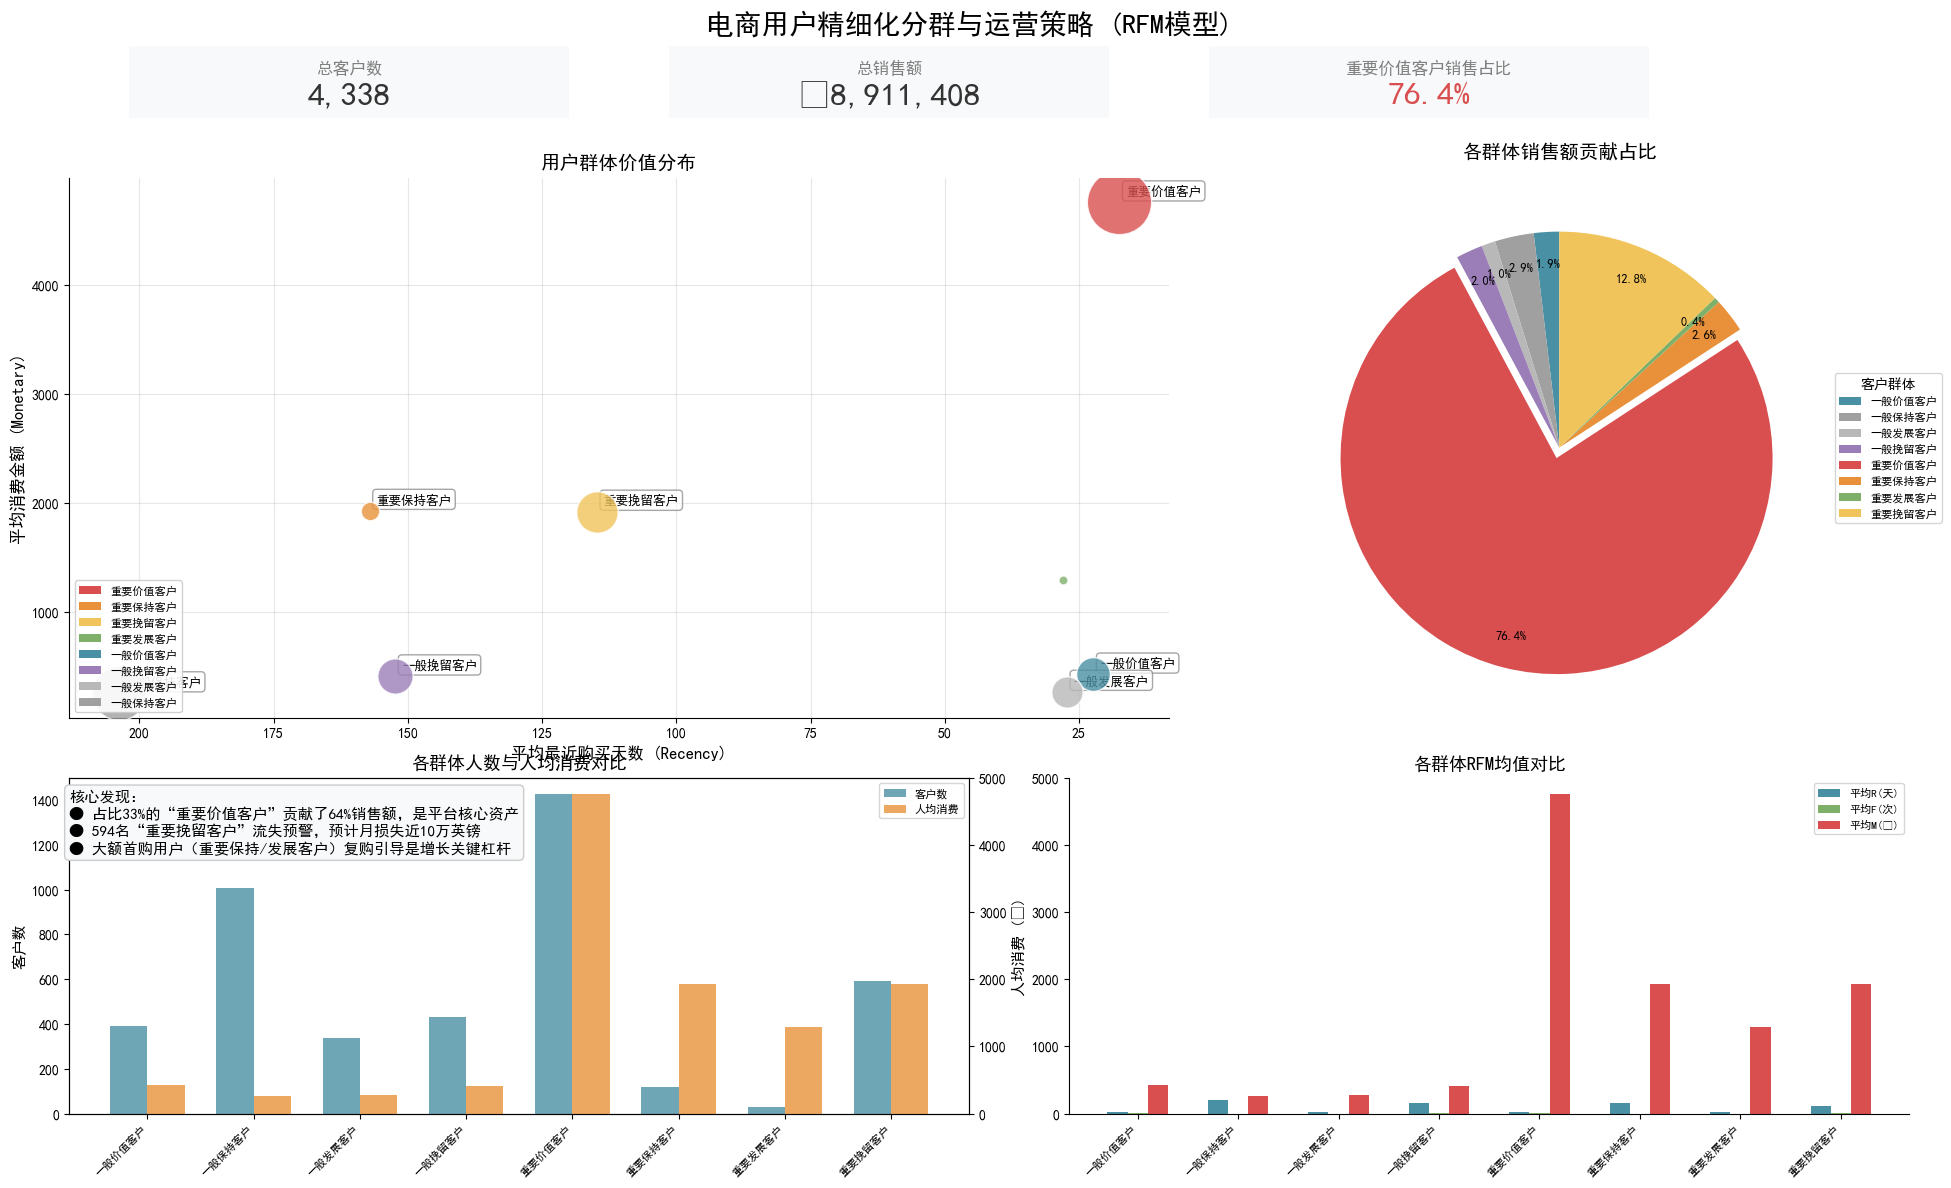

仪表盘已保存为 RFM_Dashboard.png


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

# 设置中文字体，如果系统没有SimHei，会回退到英文，不影响使用
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ------------------------------ 数据准备（基于之前的RFM结果） ------------------------------
# 确保 rfm 变量存在，如果丢失了请重跑前面的RFM分群代码

# 计算各群体关键指标
seg_stats = rfm.groupby('Customer_Segment').agg(
    count=('Recency', 'count'),
    avg_recency=('Recency', 'mean'),
    avg_frequency=('Frequency', 'mean'),
    avg_monetary=('Monetary', 'mean')
).reset_index()

# 计算总销售额（每个群体的人数 * 平均消费金额）
seg_stats['total_sales'] = seg_stats['count'] * seg_stats['avg_monetary']

# 总客户数和总销售额
total_customers = seg_stats['count'].sum()
total_sales = seg_stats['total_sales'].sum()
vip_sales_ratio = seg_stats[seg_stats['Customer_Segment'] == '重要价值客户']['total_sales'].values[0] / total_sales

# 为8个群体准备颜色，确保重要价值客户突出
segment_colors = {
    '重要价值客户': '#D94F4F',
    '重要保持客户': '#E8913A',
    '重要挽留客户': '#F0C45A',
    '重要发展客户': '#7FB069',
    '一般价值客户': '#4A90A4',
    '一般挽留客户': '#9B7EB8',
    '一般发展客户': '#B8B8B8',
    '一般保持客户': '#A0A0A0'
}

# ------------------------------ 创建仪表盘画布 ------------------------------
fig = plt.figure(figsize=(20, 12))
fig.suptitle('电商用户精细化分群与运营策略 (RFM模型)', fontsize=20, fontweight='bold', y=0.97)

# ------------------------------ 顶部：三个指标卡 ------------------------------
# 指标卡背景框
card_y = 0.88
card_height = 0.06
card_width = 0.22

# 指标卡1：总客户数
ax_card1 = fig.add_axes([0.08, card_y, card_width, card_height])
ax_card1.axis('off')
ax_card1.text(0.5, 0.7, '总客户数', ha='center', va='center', fontsize=12, color='gray')
ax_card1.text(0.5, 0.3, f'{total_customers:,}', ha='center', va='center', fontsize=24, fontweight='bold', color='#333333')
# 添加装饰框
rect = mpatches.FancyBboxPatch((0,0), 1, 1, boxstyle="round,pad=0.1", facecolor='#f8f9fa', edgecolor='#dee2e6', linewidth=1, transform=ax_card1.transAxes)
ax_card1.add_patch(rect)

# 指标卡2：总销售额
ax_card2 = fig.add_axes([0.35, card_y, card_width, card_height])
ax_card2.axis('off')
ax_card2.text(0.5, 0.7, '总销售额', ha='center', va='center', fontsize=12, color='gray')
ax_card2.text(0.5, 0.3, f'£{total_sales:,.0f}', ha='center', va='center', fontsize=24, fontweight='bold', color='#333333')
rect2 = mpatches.FancyBboxPatch((0,0), 1, 1, boxstyle="round,pad=0.1", facecolor='#f8f9fa', edgecolor='#dee2e6', linewidth=1, transform=ax_card2.transAxes)
ax_card2.add_patch(rect2)

# 指标卡3：重要价值客户销售占比
ax_card3 = fig.add_axes([0.62, card_y, card_width, card_height])
ax_card3.axis('off')
ax_card3.text(0.5, 0.7, '重要价值客户销售占比', ha='center', va='center', fontsize=12, color='gray')
ax_card3.text(0.5, 0.3, f'{vip_sales_ratio:.1%}', ha='center', va='center', fontsize=24, fontweight='bold', color='#D94F4F')
rect3 = mpatches.FancyBboxPatch((0,0), 1, 1, boxstyle="round,pad=0.1", facecolor='#f8f9fa', edgecolor='#dee2e6', linewidth=1, transform=ax_card3.transAxes)
ax_card3.add_patch(rect3)

# ------------------------------ 中部左侧：用户价值分布气泡图 ------------------------------
ax_bubble = fig.add_axes([0.05, 0.38, 0.55, 0.45])
for seg in seg_stats.itertuples():
    ax_bubble.scatter(seg.avg_recency, seg.avg_monetary, 
                      s=seg.count * 1.5,  # 气泡大小代表人数
                      c=segment_colors[seg.Customer_Segment],
                      edgecolors='white', linewidth=1, alpha=0.8, zorder=5)
    # 添加标签
    if seg.count > 100 or seg.Customer_Segment in ['重要价值客户', '重要挽留客户']:
        ax_bubble.annotate(seg.Customer_Segment, 
                           (seg.avg_recency, seg.avg_monetary),
                           xytext=(5, 5), textcoords='offset points', fontsize=9,
                           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='gray'))
ax_bubble.set_xlabel('平均最近购买天数 (Recency)', fontsize=12)
ax_bubble.set_ylabel('平均消费金额 (Monetary)', fontsize=12)
ax_bubble.set_title('用户群体价值分布', fontsize=14, fontweight='bold')
ax_bubble.invert_xaxis()  # 活跃靠左
ax_bubble.grid(True, alpha=0.3)
ax_bubble.spines['top'].set_visible(False)
ax_bubble.spines['right'].set_visible(False)

# 添加颜色图例
legend_elements = [mpatches.Patch(facecolor=segment_colors[seg], label=seg) for seg in segment_colors]
ax_bubble.legend(handles=legend_elements, loc='lower left', fontsize=8, framealpha=0.9)

# ------------------------------ 中部右侧：销售额占比环形图 ------------------------------
ax_pie = fig.add_axes([0.62, 0.38, 0.35, 0.45])
wedges, texts, autotexts = ax_pie.pie(
    seg_stats['total_sales'], 
    labels=None,
    autopct='%1.1f%%',
    colors=[segment_colors[s] for s in seg_stats['Customer_Segment']],
    startangle=90,
    pctdistance=0.85,
    explode=[0.05 if s == '重要价值客户' else 0 for s in seg_stats['Customer_Segment']],
    textprops={'fontsize': 9}
)
# 添加外部标签（避免重叠）
ax_pie.legend(
    wedges, seg_stats['Customer_Segment'],
    title="客户群体",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=8
)
ax_pie.set_title('各群体销售额贡献占比', fontsize=14, fontweight='bold', y=1.02)

# ------------------------------ 底部左侧：群体人数与人均消费对比 ------------------------------
ax_bar = fig.add_axes([0.05, 0.05, 0.45, 0.28])
x = range(len(seg_stats))
width = 0.35
bars1 = ax_bar.bar([i - width/2 for i in x], seg_stats['count'], width, 
                   label='客户数', color='#4A90A4', alpha=0.8)
ax_bar.set_ylabel('客户数', fontsize=11)
ax_bar.set_title('各群体人数与人均消费对比', fontsize=13, fontweight='bold')
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(seg_stats['Customer_Segment'], rotation=45, ha='right', fontsize=8)

ax_bar2 = ax_bar.twinx()
bars2 = ax_bar2.bar([i + width/2 for i in x], seg_stats['avg_monetary'], width, 
                     label='人均消费', color='#E8913A', alpha=0.8)
ax_bar2.set_ylabel('人均消费 (£)', fontsize=11)

# 合并图例
lines1, labels1 = ax_bar.get_legend_handles_labels()
lines2, labels2 = ax_bar2.get_legend_handles_labels()
ax_bar.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)

# ------------------------------ 底部右侧：RFM均值柱状图 ------------------------------
fig_right = fig.add_axes([0.55, 0.05, 0.42, 0.28])
x = np.arange(len(seg_stats))
width = 0.2
fig_right.bar(x - width, seg_stats['avg_recency'], width, label='平均R(天)', color='#4A90A4')
fig_right.bar(x, seg_stats['avg_frequency'], width, label='平均F(次)', color='#7FB069')
fig_right.bar(x + width, seg_stats['avg_monetary'], width, label='平均M(£)', color='#D94F4F')
fig_right.set_xticks(x)
fig_right.set_xticklabels(seg_stats['Customer_Segment'], rotation=45, ha='right', fontsize=8)
fig_right.set_title('各群体RFM均值对比', fontsize=13, fontweight='bold')
fig_right.legend(fontsize=8, loc='upper right')
fig_right.spines['top'].set_visible(False)
fig_right.spines['right'].set_visible(False)

# ------------------------------ 底部文字洞察 ------------------------------
fig.text(0.05, 0.32, '核心发现：\n● 占比33%的“重要价值客户”贡献了64%销售额，是平台核心资产\n● 594名“重要挽留客户”流失预警，预计月损失近10万英镑\n● 大额首购用户（重要保持/发展客户）复购引导是增长关键杠杆',
         fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='#f8f9fa', edgecolor='#ccc'))

# 保存图片
plt.savefig('RFM_Dashboard.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("仪表盘已保存为 RFM_Dashboard.png")